*Importing the needed libraries:*

In [ ]:
import os
import math
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass
from tqdm.notebook import tqdm

from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
from statsmodels.stats.multitest import multipletests
from lifelines.statistics import logrank_test, multivariate_logrank_test

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.table import Table
import matplotlib.transforms as mtransforms

import scipy.stats
from scipy.stats import norm, zscore, fisher_exact, chi2_contingency, mannwhitneyu

*Setting the parameters for AI-friendly export format of the plots:*

In [ ]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # embed TrueType fonts, keep text editable
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans'] 

*Reading the main dataframe with clinical metadata and flow cytometry parameters:*

In [ ]:
# upper day limit for horizoning the clinical follow-up
cutoff = 2000

print('reading the main dataframe:')
# path to the full dataset excel with clinical metadata and flow cytometry parameters for the patients:
full_dataset_clinmetadata_flowcytometrydata_path = ''
d35_input_full = pd.read_excel(full_dataset_clinmetadata_flowcytometrydata_path)
d35_input_full_copy = d35_input_full[(d35_input_full['OC_d35_PassCrit_FCAnalysis'] == 'Yes') | (d35_input_full['VC_d35_PassCrit_FCAnalysis'] == 'Yes')]

PERCENT_FEATURES = [c for c in d35_input_full_copy.columns if ' of ' in c]
myeloid_endings = [' of DC/HLA-DRpos_APC',' of Monocytes',' of Myeloid']
myeloid_endings_and_CD45pos = [' of DC/HLA-DRpos_APC',' of Monocytes',' of Myeloid', ' of CD45pos']
myeloid_child = set(element.split(' of ')[0] for element in PERCENT_FEATURES if element.endswith(tuple(myeloid_endings)))
myeloid_params_exclude = [element for element in PERCENT_FEATURES if element.startswith(tuple(myeloid_child)) and element.endswith(tuple(myeloid_endings_and_CD45pos))]
PERCENT_FEATURES = list(set(PERCENT_FEATURES) - set(myeloid_params_exclude))

PERCENT_FEATURES_renamer = {}
to_rename = [element for element in PERCENT_FEATURES if 'LowLevel' in element]
for element in to_rename:
    PERCENT_FEATURES_renamer[element] = element.replace('LowLevel ', 'High Resolution ')
d35_input_full_copy = d35_input_full_copy.rename(columns = PERCENT_FEATURES_renamer)
PERCENT_FEATURES = [element.replace('LowLevel ', 'High Resolution ') for element in PERCENT_FEATURES]

RATIO_FEATURES   = [c for c in d35_input_full_copy.columns if '-to-' in c]
OUTCOME_COLS = {
    "RFS": {"time": 'Time_to_Relapse_from_TPL', "event": 'Relapse_Present_1_NotObserved_0'},
    "OS":  {"time": 'Time_to_Death_from_TPL',  "event": 'Death_Present_1_NotObserved_0'},
    "aGVHD": {"time": "Time_to_aGVHD", "event": "aGVHD_grading_by_Katja"},
    "cGVHD": {"time": "Time_to_cGVHD", "event": "cGVHD_grading_by_Katja"},
}

d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'] = round(d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'], 0)
d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'] = d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'].astype("Int64")
d35_input_full_copy['Cutoff_Plus_SamplingDay'] = cutoff + d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']

# version with horizoning by a sum of cutoff + sampling day & then landmarking (X days post sampling)
d35_input_full_copy[OUTCOME_COLS['RFS']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['RFS']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], 0, d35_input_full_copy[OUTCOME_COLS['RFS']['event']])
d35_input_full_copy[OUTCOME_COLS['RFS']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['RFS']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy[OUTCOME_COLS['RFS']['time']])
d35_input_full_copy[OUTCOME_COLS['OS']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['OS']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], 0, d35_input_full_copy[OUTCOME_COLS['OS']['event']])
d35_input_full_copy[OUTCOME_COLS['OS']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['OS']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy[OUTCOME_COLS['OS']['time']])
d35_input_full_copy[OUTCOME_COLS['aGVHD']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], 0, d35_input_full_copy[OUTCOME_COLS['aGVHD']['event']])
d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']])
d35_input_full_copy[OUTCOME_COLS['cGVHD']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], 0, d35_input_full_copy[OUTCOME_COLS['cGVHD']['event']])
d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] >= d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy['Cutoff_Plus_SamplingDay'], d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']])

d35_input_full_copy['Relapse_Present_1_NotObserved_0'] = d35_input_full_copy['Relapse_Present_1_NotObserved_0'].astype("Int64")
d35_input_full_copy['aGVHD_grading_by_Katja'] = d35_input_full_copy['aGVHD_grading_by_Katja'].astype("Int64")
d35_input_full_copy['cGVHD_grading_by_Katja'] = d35_input_full_copy['cGVHD_grading_by_Katja'].astype("Int64")
d35_input_full_copy['MAX_FOLLOW_UP'] = d35_input_full_copy[['Time_to_aGVHD', 'Time_to_cGVHD',
                                                            'Time_to_Relapse_from_TPL','Time_to_Death_from_TPL']].max(axis = 1)


d35_input_full_copy['Time_to_Death_from_TPL'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['Time_to_Relapse_from_TPL'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['Time_to_aGVHD'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
# only 65 patients (40 in VC and 25 in OC)
d35_input_full_copy['Time_to_cGVHD'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['MAX_FOLLOW_UP'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']

reading the main dataframe:


*Calculating different score versions:*

In [7]:
score_df = df_multivariate.copy()

score_name = 'CD8TEMGeneral_CD4TCM_CD4TCMNVratio_Score'

parameters_unique = [
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM',
    'CD4 CCR7mid CD45RA- of T',
    'CD4_Naive+CD4_TCM-to-CD4_rest',
    "CD56dim NK CD57+ GPR56+ of Lymphocytes",
    'High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes'
]

direction = {
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'protective',
    'CD4 CCR7mid CD45RA- of T': 'non-protective',
    'CD4_Naive+CD4_TCM-to-CD4_rest': 'non-protective',
    "CD56dim NK CD57+ GPR56+ of Lymphocytes": 'protective',
    'High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes': 'protective',
}

def sign_intepreter(parameter):
    if direction[parameter] == 'protective':
        return [1,0]
    else:
        return [0,1]

cutoffs = {}
for parameter in parameters_unique:
    cutoffs[parameter] = {
        'OC': np.median(score_df[score_df['Cohort'] == 'OC'][parameter]),
        'VC': np.median(score_df[score_df['Cohort'] == 'VC'][parameter])
    }

for parameter in cutoffs:
    score_df[f'{parameter}_SCORE'] = np.where(score_df['Cohort'] == 'OC',
                                                     np.where(score_df[parameter] > cutoffs[parameter]['OC'], sign_intepreter(parameter)[0], sign_intepreter(parameter)[1]),
                                                     np.where(score_df[parameter] > cutoffs[parameter]['VC'], sign_intepreter(parameter)[0], sign_intepreter(parameter)[1])
                                                    )
for score_name in [
    'CD8TEMGeneral_CD4TCM_CD4TCMNVratio_Score',
    'CD8TEMGeneral_CD4TCM_CD56dimNK_Score',
    'CD8TEMGeneral_CD4TCM_HighResCD56dimNK_Score',
    'CD8TEMGeneral_CD4TCMNVratio_CD56dimNK_Score',
    'CD8TEMGeneral_CD4TCMNVratio_HighResCD56dimNK_Score'
]:
    if score_name == 'CD8TEMGeneral_CD4TCM_CD4TCMNVratio_Score':
        parameters = {
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GvL_Score',
            'CD4 CCR7mid CD45RA- of T': 'GvHD_Score',
            'CD4_Naive+CD4_TCM-to-CD4_rest': 'GvHD_Score'
        }
    elif score_name == 'CD8TEMGeneral_CD4TCM_CD56dimNK_Score':
        parameters = {
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GvL_Score',
            "CD56dim NK CD57+ GPR56+ of Lymphocytes": 'GvHD_Score',
            'CD4 CCR7mid CD45RA- of T': 'GvHD_Score',
        }
    elif score_name == 'CD8TEMGeneral_CD4TCM_HighResCD56dimNK_Score':
        parameters = {
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GvL_Score',
            'High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes': 'GvHD_Score',
            'CD4 CCR7mid CD45RA- of T': 'GvHD_Score',
        }
    elif score_name == 'CD8TEMGeneral_CD4TCMNVratio_CD56dimNK_Score':
        parameters = {
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GvL_Score',
            "CD56dim NK CD57+ GPR56+ of Lymphocytes": 'GvHD_Score',
            'CD4_Naive+CD4_TCM-to-CD4_rest': 'GvHD_Score'
        }
    elif score_name == 'CD8TEMGeneral_CD4TCMNVratio_HighResCD56dimNK_Score':
        parameters = {
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GvL_Score',
            'High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes': 'GvHD_Score',
            'CD4_Naive+CD4_TCM-to-CD4_rest': 'GvHD_Score'
        }
    
    GvL_params = list({k:v for k,v in parameters.items() if v == 'GvL_Score'}.keys())
    GvHD_params = list({k:v for k,v in parameters.items() if v == 'GvHD_Score'}.keys())
    score_df['GvL_Score'] = score_df[[f'{element}_SCORE' for element in GvL_params]].sum(axis = 1)
    score_df['GvHD_Score'] = score_df[[f'{element}_SCORE' for element in GvHD_params]].sum(axis = 1)
    score_df[score_name] = np.where((score_df['GvL_Score'] == len({k:v for k,v in parameters.items() if v == 'GvL_Score'})) & 
                                            (score_df['GvHD_Score'] == len({k:v for k,v in parameters.items() if v == 'GvHD_Score'})), 1, 0)
    score_df.drop(['GvL_Score', 'GvHD_Score'], axis = 1, inplace = True)

score_df['Cohort'] = score_df['Cohort'].replace({'OC': 'Cohort 1', 'VC': 'Cohort 2'})
df_multivariate_OC = score_df[score_df['Cohort'] == 'Cohort 1']
df_multivariate_VC = score_df[score_df['Cohort'] == 'Cohort 2']

*Recording the composition of favorable ICC35 score subgroups across different ICC35 versions:*

In [8]:
sets_of_patients  = {
    'Cohort 1': {
        'CD8TEMGeneral_CD4TCM_CD4TCMNVratio_Score': [],
        'CD8TEMGeneral_CD4TCM_CD56dimNK_Score': [],
        'CD8TEMGeneral_CD4TCMNVratio_HighResCD56dimNK_Score': [],
    },
    'Cohort 2': {
        'CD8TEMGeneral_CD4TCM_CD4TCMNVratio_Score': [],
        'CD8TEMGeneral_CD4TCM_CD56dimNK_Score': [],
        'CD8TEMGeneral_CD4TCMNVratio_HighResCD56dimNK_Score': [],
    }
}

for cohort, df in zip(['Cohort 1', 'Cohort 2'],[df_multivariate_OC, df_multivariate_VC]):
    for score in [
        'CD8TEMGeneral_CD4TCM_CD4TCMNVratio_Score',
        'CD8TEMGeneral_CD4TCM_CD56dimNK_Score',
        'CD8TEMGeneral_CD4TCMNVratio_HighResCD56dimNK_Score'
    ]:
        sets_of_patients[cohort][score] = df[df[score] == 1]['ISH_ID_TPL_date_MERGED'].to_list()

*Plotting the Venn diagrams with overlap between ICC35 favorable groups:*

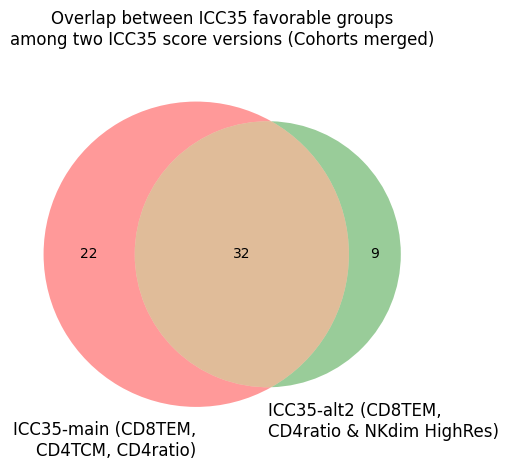

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn2

# cohort = 'Cohort 2'
cohort = 'Cohorts merged'

if cohort != 'Cohorts merged':
      set_ICC35_normal = set(sets_of_patients[cohort]['CD8TEMGeneral_CD4TCM_CD4TCMNVratio_Score'])
      set_ICC35_CD4TCM_NKdimGEN = set(sets_of_patients[cohort]['CD8TEMGeneral_CD4TCM_CD56dimNK_Score'])
      set_ICC35_CD4ratio_NKdimHR = set(sets_of_patients[cohort]['CD8TEMGeneral_CD4TCMNVratio_HighResCD56dimNK_Score'])
else:
    set_ICC35_normal = set(sets_of_patients['Cohort 1']['CD8TEMGeneral_CD4TCM_CD4TCMNVratio_Score'] + sets_of_patients['Cohort 2']['CD8TEMGeneral_CD4TCM_CD4TCMNVratio_Score'])
    set_ICC35_CD4TCM_NKdimGEN = set(sets_of_patients['Cohort 1']['CD8TEMGeneral_CD4TCM_CD56dimNK_Score'] + sets_of_patients['Cohort 2']['CD8TEMGeneral_CD4TCM_CD56dimNK_Score'])
    set_ICC35_CD4ratio_NKdimHR = set(sets_of_patients['Cohort 1']['CD8TEMGeneral_CD4TCMNVratio_HighResCD56dimNK_Score'] + sets_of_patients['Cohort 2']['CD8TEMGeneral_CD4TCMNVratio_HighResCD56dimNK_Score'])  

# venn3([set_ICC35_normal, set_ICC35_CD4TCM_NKdimGEN, set_ICC35_CD4ratio_NKdimHR],
#       ('ICC35-main (CD8TEM,\nCD4TCM, CD4ratio)', 'ICC35-alt1 (CD8TEM,\nCD4TCM & NKdim Gen)', 'ICC35-alt2 (CD8TEM,\nCD4ratio & NKdim HighRes)'))
# plt.title(f'Overlap between ICC35 favorable groups\namong three ICC35 score versions ({cohort})', pad = 20)
# plt.tight_layout()
# # specify the output directory for Venn diagrams:
# base_dir = ''
# plt.savefig(f'{base_dir}/{cohort.replace(" ","")}_ICC35main_ICC35_CD4TCM_NKdimGen_ICC35_CD4ratio_NKdimHR_favorable_groups_overlaps.pdf', bbox_inches = 'tight')
# plt.show()

# venn2([set_ICC35_normal, set_ICC35_CD4TCM_NKdimGEN],
#       ('ICC35-main (CD8TEM,\nCD4TCM, CD4ratio)', 'ICC35-alt1 (CD8TEM,\nCD4TCM & NKdim Gen)'))
# plt.title(f'Overlap between ICC35 favorable groups\namong two ICC35 score versions ({cohort})', pad = 20)
# plt.tight_layout()
# # specify the output directory for Venn diagrams:
# base_dir = ''
# plt.savefig(f'{base_dir}/{cohort.replace(" ","")}_ICC35main_ICC35_CD4TCM_NKdimGen_favorable_groups_overlaps.pdf', bbox_inches = 'tight')
# plt.show()

venn2([set_ICC35_normal, set_ICC35_CD4ratio_NKdimHR],
      ('ICC35-main (CD8TEM,\nCD4TCM, CD4ratio)', 'ICC35-alt2 (CD8TEM,\nCD4ratio & NKdim HighRes)'))
plt.title(f'Overlap between ICC35 favorable groups\namong two ICC35 score versions ({cohort})', pad = 20)
plt.tight_layout()
# specify the output directory for Venn diagrams:
base_dir = ''
plt.savefig(f'{base_dir}/{cohort.replace(" ","")}_ICC35main_ICC35_CD4ratio_NKdimHR_favorable_groups_overlaps.pdf', bbox_inches = 'tight')
plt.show()